# Transformer Training: Genre Conditioned Story Generation

This notebook:
- Loads processed datasets
- Builds tokenizer and vocabulary
- Creates PyTorch datasets and dataloaders
- Implements a Transformer from scratch
- Trains the model for conditional story generation
- Tracks training metrics and saves checkpoints

# 1. Import

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import pickle
import math

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cpu


# 2. Load Processsed Splits

In [3]:
train_df = pd.read_csv("../data/train.csv")
val_df = pd.read_csv("../data/val.csv")
test_df = pd.read_csv("../data/test.csv")

print(len(train_df), len(val_df), len(test_df))

699 150 151


# 3. Build Genre Conditioned Text

In [4]:
def make_text(row):
    genre = row["genre"].replace(" ", "_")
    return f"<GENRE_{genre}> " + row["story"]

train_texts = train_df.apply(make_text, axis=1).tolist()
val_texts = val_df.apply(make_text, axis=1).tolist()
test_texts = test_df.apply(make_text, axis=1).tolist()

# 4. Build Vocabulary

In [5]:
SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]

counter = Counter()

for text in train_texts:
    counter.update(text.lower().split())

vocab = SPECIAL_TOKENS + sorted(counter.keys())

word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

VOCAB_SIZE = len(vocab)

print("Vocabulary size:", VOCAB_SIZE)

Vocabulary size: 28007


In [6]:
def encode(text):
    return [
        word2idx.get(word, word2idx["<UNK>"])
        for word in text.lower().split()
    ]

In [7]:
MAX_LEN = 256

In [8]:
def prepare_sequence(text):
    seq = [word2idx["<SOS>"]]

    seq += encode(text)

    seq += [word2idx["<EOS>"]]

    seq = seq[:MAX_LEN]

    seq += [word2idx["<PAD>"]] * (MAX_LEN - len(seq))

    return seq

# 5. Encode all data

In [9]:
train_sequences = [prepare_sequence(t) for t in train_texts]
val_sequences = [prepare_sequence(t) for t in val_texts]

train_sequences = np.array(train_sequences)
val_sequences = np.array(val_sequences)

print(train_sequences.shape)

(699, 256)


In [10]:
class StoryDataset(Dataset):

    def __init__(self, sequences):
        self.sequences = torch.tensor(sequences, dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):

        seq = self.sequences[idx]

        x = seq[:-1]
        y = seq[1:]

        return x, y

# Dataloaders

In [11]:
BATCH_SIZE = 16

train_dataset = StoryDataset(train_sequences)
val_dataset = StoryDataset(val_sequences)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [12]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

In [13]:
class StoryTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model=256,
        nhead=4,
        num_layers=4,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)

        self.positional = PositionalEncoding(d_model)

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dropout=dropout,
                batch_first=True
            ),
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):

        x = self.embedding(x)

        x = self.positional(x)

        x = self.transformer(x)

        return self.fc(x)

In [14]:
model = StoryTransformer(VOCAB_SIZE).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<PAD>"])

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [15]:
NUM_EPOCHS = 10

train_losses = []

for epoch in range(NUM_EPOCHS):

    model.train()

    total_loss = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            y.reshape(-1)
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

Epoch 1: Loss = 8.2165
Epoch 2: Loss = 6.8016
Epoch 3: Loss = 6.3647
Epoch 4: Loss = 6.0140
Epoch 5: Loss = 5.7291
Epoch 6: Loss = 5.4914
Epoch 7: Loss = 5.2813
Epoch 8: Loss = 5.0831
Epoch 9: Loss = 4.9027
Epoch 10: Loss = 4.7067


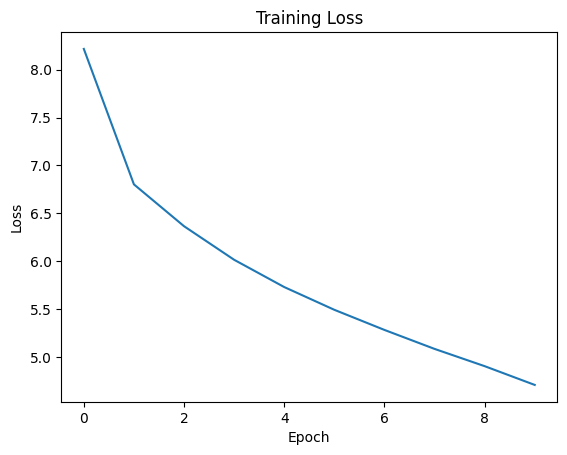

In [16]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [17]:
torch.save(model.state_dict(), "../checkpoints/story_transformer.pt")

In [18]:
def generate_text(prompt, max_tokens=50):

    model.eval()

    tokens = prepare_sequence(prompt)

    tokens = torch.tensor(tokens).unsqueeze(0).to(DEVICE)

    generated = []

    with torch.no_grad():

        for _ in range(max_tokens):

            logits = model(tokens)

            next_token = logits[0, -1].argmax().item()

            generated.append(next_token)

            if next_token == word2idx["<EOS>"]:
                break

            tokens = torch.cat([
                tokens,
                torch.tensor([[next_token]]).to(DEVICE)
            ], dim=1)

    return " ".join([
        idx2word.get(t, "<UNK>")
        for t in generated
    ])

In [19]:
prompt = "<GENRE_Horror> the house was silent"

print(generate_text(prompt))

<EOS>
